# Credit Scoring - Advanced Boosting Models

This notebook continues the credit scoring model research using
advanced gradient boosting algorithms.

The previous modeling stage evaluated:

- Logistic Regression;
- Random Forest;
- HistGradientBoosting.

The tuned HistGradientBoosting model achieved the strongest validation
performance so far.

This notebook evaluates more advanced boosting algorithms and compares
them with the previous best model.

## 1. Imports & Configuration

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


RANDOM_STATE = 42

## 2. Load Prepared Data

In [2]:
X_train = pd.read_csv('data/X_train.csv')
X_valid = pd.read_csv('data/X_valid.csv')

y_train = pd.read_csv('data/y_train.csv').squeeze()
y_valid = pd.read_csv('data/y_valid.csv').squeeze()

In [3]:
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)
print('y_train:', y_train.shape)
print('y_valid:', y_valid.shape)

X_train: (83844, 14)
X_valid: (20961, 14)
y_train: (83844,)
y_valid: (20961,)


In [4]:
features = [
    'RevolvingUtilizationOfUnsecuredLines_log',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio_log',
    'MonthlyIncome_log',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'HasUnknownDelinquencyHistory'
]

## 3. XGBoost - Baseline

XGBoost builds trees sequentially, where each new tree attempts to
reduce the errors of the current ensemble.

The baseline model is trained first without hyperparameter tuning to
establish its initial performance relative to HistGradientBoosting.

In [5]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss'
)

In [6]:
xgb_model.fit(
    X_train[features],
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
xgb_valid_proba = xgb_model.predict_proba(
    X_valid[features]
)[:, 1]

In [8]:
xgb_roc_auc = roc_auc_score(
    y_valid,
    xgb_valid_proba
)

xgb_pr_auc = average_precision_score(
    y_valid,
    xgb_valid_proba
)

print(f'XGBoost ROC-AUC: {xgb_roc_auc:.4f}')
print(f'XGBoost PR-AUC: {xgb_pr_auc:.4f}')

XGBoost ROC-AUC: 0.8668
XGBoost PR-AUC: 0.3989


In [9]:
baseline_comparison = pd.DataFrame({
    'Model': [
        'HistGradientBoosting Tuned',
        'XGBoost Baseline'
    ],
    'ROC-AUC': [
        0.866,
        xgb_roc_auc
    ],
    'PR-AUC': [
        0.397,
        xgb_pr_auc
    ]
})

baseline_comparison

,Model,ROC-AUC,PR-AUC
0,HistGradientBoosting Tuned,0.866000,0.397000
1,XGBoost Baseline,0.866802,0.398892


## 4. XGBoost - Hyperparameter Tuning

The baseline XGBoost model slightly outperformed the tuned
HistGradientBoosting model.

In [10]:
xgb_param_distributions = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.02, 0.05, 0.08, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0]
}

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [12]:
xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    param_distributions=xgb_param_distributions,
    n_iter=40,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [13]:
xgb_random_search.fit(
    X_train[features],
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.02, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimat

In [14]:
print(
    f'Best XGBoost CV PR-AUC: '
    f'{xgb_random_search.best_score_:.4f}'
)

print('\nBest parameters:')
print(xgb_random_search.best_params_)

Best XGBoost CV PR-AUC: 0.3982

Best parameters:
{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.6}


In [15]:
best_xgb = xgb_random_search.best_estimator_

best_xgb_valid_proba = best_xgb.predict_proba(
    X_valid[features]
)[:, 1]

In [16]:
best_xgb_roc_auc = roc_auc_score(
    y_valid,
    best_xgb_valid_proba
)

best_xgb_pr_auc = average_precision_score(
    y_valid,
    best_xgb_valid_proba
)

print(f'Tuned XGBoost ROC-AUC: {best_xgb_roc_auc:.4f}')
print(f'Tuned XGBoost PR-AUC: {best_xgb_pr_auc:.4f}')

Tuned XGBoost ROC-AUC: 0.8672
Tuned XGBoost PR-AUC: 0.4044


In [17]:
xgb_comparison = pd.DataFrame({
    'Model': [
        'HistGradientBoosting Tuned',
        'XGBoost Baseline',
        'XGBoost Tuned'
    ],
    'ROC-AUC': [
        0.8660,
        xgb_roc_auc,
        best_xgb_roc_auc
    ],
    'PR-AUC': [
        0.3970,
        xgb_pr_auc,
        best_xgb_pr_auc
    ]
})

xgb_comparison

,Model,ROC-AUC,PR-AUC
0,HistGradientBoosting Tuned,0.866000,0.397000
1,XGBoost Baseline,0.866802,0.398892
2,XGBoost Tuned,0.867174,0.404439


In [18]:
xgb_local_params = {
    'n_estimators': [700, 900, 1100],
    'learning_rate': [0.01, 0.02, 0.03],
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'reg_alpha': [0.5, 1.0, 2.0],
    'reg_lambda': [5.0, 7.0, 10.0]
}

In [19]:
xgb_local_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    param_distributions=xgb_local_params,
    n_iter=40,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [20]:
xgb_local_search.fit(
    X_train[features],
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.6, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, `

In [21]:
print(
    f'Best Local XGBoost CV PR-AUC: '
    f'{xgb_local_search.best_score_:.4f}'
)

print('\nBest parameters:')
print(xgb_local_search.best_params_)

Best Local XGBoost CV PR-AUC: 0.3996

Best parameters:
{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 1100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [22]:
best_xgb_local = xgb_local_search.best_estimator_

best_xgb_local_proba = best_xgb_local.predict_proba(
    X_valid[features]
)[:, 1]

In [23]:
local_xgb_roc_auc = roc_auc_score(
    y_valid,
    best_xgb_local_proba
)

local_xgb_pr_auc = average_precision_score(
    y_valid,
    best_xgb_local_proba
)

print(f'Local XGBoost ROC-AUC: {local_xgb_roc_auc:.4f}')
print(f'Local XGBoost PR-AUC: {local_xgb_pr_auc:.4f}')

Local XGBoost ROC-AUC: 0.8679
Local XGBoost PR-AUC: 0.4037


In [24]:
final_xgb = best_xgb

In [25]:
xgb_final_comparison = pd.DataFrame({
    'Model': [
        'HistGradientBoosting Tuned',
        'XGBoost Baseline',
        'XGBoost Tuned',
        'XGBoost Local Search'
    ],
    'ROC-AUC': [
        0.8660,
        xgb_roc_auc,
        best_xgb_roc_auc,
        local_xgb_roc_auc
    ],
    'PR-AUC': [
        0.3970,
        xgb_pr_auc,
        best_xgb_pr_auc,
        local_xgb_pr_auc
    ]
})

xgb_final_comparison

,Model,ROC-AUC,PR-AUC
0,HistGradientBoosting Tuned,0.866000,0.397000
1,XGBoost Baseline,0.866802,0.398892
2,XGBoost Tuned,0.867174,0.404439
3,XGBoost Local Search,0.867865,0.403737


## XGBoost - Conclusion

Hyperparameter tuning improved the XGBoost baseline, especially in PR-AUC.

A second local search slightly improved ROC-AUC but did not improve PR-AUC.

Because PR-AUC is the primary tuning metric for this imbalanced
classification problem, the first tuned XGBoost model is retained as
the current best XGBoost configuration.

## 5. LightGBM - Baseline

LightGBM is evaluated as another gradient boosting implementation.

In [26]:
lgbm_model = LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [27]:
lgbm_model.fit(
    X_train[features],
    y_train
)

[LightGBM] [Info] Number of positive: 5560, number of negative: 78284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 967
[LightGBM] [Info] Number of data points in the train set: 83844, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066314 -> initscore=-2.644745
[LightGBM] [Info] Start training from score -2.644745


,learning_rate,0.05
,n_estimators,500
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [28]:
lgbm_valid_proba = lgbm_model.predict_proba(
    X_valid[features]
)[:, 1]

In [29]:
lgbm_roc_auc = roc_auc_score(
    y_valid,
    lgbm_valid_proba
)

lgbm_pr_auc = average_precision_score(
    y_valid,
    lgbm_valid_proba
)

print(f'LightGBM ROC-AUC: {lgbm_roc_auc:.4f}')
print(f'LightGBM PR-AUC: {lgbm_pr_auc:.4f}')

LightGBM ROC-AUC: 0.8639
LightGBM PR-AUC: 0.3898


In [30]:
boosting_comparison = pd.DataFrame({
    'Model': [
        'HistGradientBoosting Tuned',
        'XGBoost Tuned',
        'LightGBM Baseline'
    ],
    'ROC-AUC': [
        0.8660,
        best_xgb_roc_auc,
        lgbm_roc_auc
    ],
    'PR-AUC': [
        0.3970,
        best_xgb_pr_auc,
        lgbm_pr_auc
    ]
})

boosting_comparison

,Model,ROC-AUC,PR-AUC
0,HistGradientBoosting Tuned,0.866000,0.397000
1,XGBoost Tuned,0.867174,0.404439
2,LightGBM Baseline,0.863873,0.389849


## 6. CatBoost - Baseline

CatBoost is evaluated as another gradient boosting implementation.

Although CatBoost is particularly effective with categorical features,
it can also provide strong performance on numerical tabular datasets.

In [31]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    loss_function='Logloss',
    random_seed=RANDOM_STATE,
    verbose=False
)

In [32]:
catboost_model.fit(
    X_train[features],
    y_train
)

CatBoostClassifier(depth=6, iterations=500, l2_leaf_reg=3.0, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [33]:
catboost_valid_proba = catboost_model.predict_proba(
    X_valid[features]
)[:, 1]

In [34]:
catboost_roc_auc = roc_auc_score(
    y_valid,
    catboost_valid_proba
)

catboost_pr_auc = average_precision_score(
    y_valid,
    catboost_valid_proba
)

print(f'CatBoost ROC-AUC: {catboost_roc_auc:.4f}')
print(f'CatBoost PR-AUC: {catboost_pr_auc:.4f}')

CatBoost ROC-AUC: 0.8678
CatBoost PR-AUC: 0.3941


In [35]:
boosting_comparison = pd.DataFrame({
    'Model': [
        'HistGradientBoosting Tuned',
        'XGBoost Tuned',
        'LightGBM Baseline',
        'CatBoost Baseline'
    ],
    'ROC-AUC': [
        0.8660,
        best_xgb_roc_auc,
        lgbm_roc_auc,
        catboost_roc_auc
    ],
    'PR-AUC': [
        0.3970,
        best_xgb_pr_auc,
        lgbm_pr_auc,
        catboost_pr_auc
    ]
})

boosting_comparison

,Model,ROC-AUC,PR-AUC
0,HistGradientBoosting Tuned,0.866000,0.397000
1,XGBoost Tuned,0.867174,0.404439
2,LightGBM Baseline,0.863873,0.389849
3,CatBoost Baseline,0.867800,0.394147


## 7. CatBoost - Hyperparameter Tuning

The CatBoost baseline achieved competitive performance, including the
highest ROC-AUC among the current models.

In [36]:
catboost_param_distributions = {
    'iterations': [300, 500, 700, 1000],
    'learning_rate': [0.02, 0.05, 0.08, 0.1],
    'depth': [4, 5, 6, 7, 8],
    'l2_leaf_reg': [1.0, 3.0, 5.0, 10.0],
    'random_strength': [0.0, 0.5, 1.0, 2.0],
    'bagging_temperature': [0.0, 0.5, 1.0, 2.0]
}

In [37]:
catboost_random_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        loss_function='Logloss',
        random_seed=RANDOM_STATE,
        verbose=False
    ),
    param_distributions=catboost_param_distributions,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [38]:
catboost_random_search.fit(
    X_train[features],
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bagging_temperature': [0.0, 0.5, ...], 'depth': [4, 5, ...], 'iterations': [300, 500, ...], 'l2_leaf_reg': [1.0, 3.0, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``ref

In [39]:
print(
    f'Best CatBoost CV PR-AUC: '
    f'{catboost_random_search.best_score_:.4f}'
)

print('\nBest parameters:')
print(catboost_random_search.best_params_)

Best CatBoost CV PR-AUC: 0.4000

Best parameters:
{'random_strength': 2.0, 'learning_rate': 0.02, 'l2_leaf_reg': 5.0, 'iterations': 500, 'depth': 6, 'bagging_temperature': 1.0}


In [40]:
best_catboost = catboost_random_search.best_estimator_

In [41]:
best_catboost_valid_proba = best_catboost.predict_proba(
    X_valid[features]
)[:, 1]

In [42]:
best_catboost_roc_auc = roc_auc_score(
    y_valid,
    best_catboost_valid_proba
)

best_catboost_pr_auc = average_precision_score(
    y_valid,
    best_catboost_valid_proba
)

print(f'Tuned CatBoost ROC-AUC: {best_catboost_roc_auc:.4f}')
print(f'Tuned CatBoost PR-AUC: {best_catboost_pr_auc:.4f}')

Tuned CatBoost ROC-AUC: 0.8671
Tuned CatBoost PR-AUC: 0.4072


In [43]:
boosting_comparison = pd.DataFrame({
    'Model': [
        'HistGradientBoosting Tuned',
        'XGBoost Tuned',
        'LightGBM Baseline',
        'CatBoost Baseline',
        'CatBoost Tuned'
    ],
    'ROC-AUC': [
        0.8660,
        best_xgb_roc_auc,
        lgbm_roc_auc,
        catboost_roc_auc,
        best_catboost_roc_auc
    ],
    'PR-AUC': [
        0.3970,
        best_xgb_pr_auc,
        lgbm_pr_auc,
        catboost_pr_auc,
        best_catboost_pr_auc
    ]
})

boosting_comparison.sort_values(
    'PR-AUC',
    ascending=False
)

,Model,ROC-AUC,PR-AUC
4,CatBoost Tuned,0.867100,0.407215
1,XGBoost Tuned,0.867174,0.404439
0,HistGradientBoosting Tuned,0.866000,0.397000
3,CatBoost Baseline,0.867800,0.394147
2,LightGBM Baseline,0.863873,0.389849


## 8. Final Boosting Comparison

The evaluated boosting algorithms are compared using ROC-AUC and PR-AUC.

Because the target class is highly imbalanced, PR-AUC is used as the
primary metric for model selection.

The tuned CatBoost model achieves the highest PR-AUC and is selected
as the leading candidate for further evaluation.

In [44]:
catboost_random_search.best_params_

{'random_strength': 2.0,
 'learning_rate': 0.02,
 'l2_leaf_reg': 5.0,
 'iterations': 500,
 'depth': 6,
 'bagging_temperature': 1.0}

In [45]:
catboost_local_params = {
    'iterations': [400, 500, 700, 900],
    'learning_rate': [0.01, 0.015, 0.02, 0.03],
    'depth': [5, 6, 7],
    'l2_leaf_reg': [3.0, 5.0, 7.0, 10.0],
    'random_strength': [1.0, 2.0, 3.0, 5.0],
    'bagging_temperature': [0.5, 1.0, 1.5, 2.0]
}

In [46]:
catboost_local_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        loss_function='Logloss',
        random_seed=RANDOM_STATE,
        verbose=False
    ),
    param_distributions=catboost_local_params,
    n_iter=40,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [47]:
catboost_local_search.fit(
    X_train[features],
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bagging_temperature': [0.5, 1.0, ...], 'depth': [5, 6, ...], 'iterations': [400, 500, ...], 'l2_leaf_reg': [3.0, 5.0, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``ref

In [48]:
print(
    f'Best Local CatBoost CV PR-AUC: '
    f'{catboost_local_search.best_score_:.4f}'
)

print('\nBest parameters:')
print(catboost_local_search.best_params_)

Best Local CatBoost CV PR-AUC: 0.4003

Best parameters:
{'random_strength': 1.0, 'learning_rate': 0.01, 'l2_leaf_reg': 7.0, 'iterations': 900, 'depth': 5, 'bagging_temperature': 2.0}


In [49]:
best_catboost_local = (
    catboost_local_search.best_estimator_
)

In [50]:
best_catboost_local_proba = (
    best_catboost_local.predict_proba(
        X_valid[features]
    )[:, 1]
)

In [51]:
local_catboost_roc_auc = roc_auc_score(
    y_valid,
    best_catboost_local_proba
)

local_catboost_pr_auc = average_precision_score(
    y_valid,
    best_catboost_local_proba
)

print(
    f'Local CatBoost ROC-AUC: '
    f'{local_catboost_roc_auc:.4f}'
)

print(
    f'Local CatBoost PR-AUC: '
    f'{local_catboost_pr_auc:.4f}'
)

Local CatBoost ROC-AUC: 0.8670
Local CatBoost PR-AUC: 0.4064


In [52]:
catboost_tuning_comparison = pd.DataFrame({
    'Model': [
        'CatBoost Tuned',
        'CatBoost Local Search'
    ],
    'ROC-AUC': [
        best_catboost_roc_auc,
        local_catboost_roc_auc
    ],
    'PR-AUC': [
        best_catboost_pr_auc,
        local_catboost_pr_auc
    ]
})

catboost_tuning_comparison

,Model,ROC-AUC,PR-AUC
0,CatBoost Tuned,0.867100,0.407215
1,CatBoost Local Search,0.866958,0.406398


In [53]:
final_catboost = best_catboost

## 9. Probability Calibration

The final CatBoost model provides probability estimates through
`predict_proba`.

Before using these probabilities in the application, we evaluate
whether the predicted probabilities correspond well to the observed
default frequencies.

In [54]:
catboost_brier = brier_score_loss(
    y_valid,
    best_catboost_valid_proba
)

print(
    f'CatBoost Brier Score: '
    f'{catboost_brier:.4f}'
)

CatBoost Brier Score: 0.0485


In [55]:
prob_true, prob_pred = calibration_curve(
    y_valid,
    best_catboost_valid_proba,
    n_bins=10,
    strategy='quantile'
)

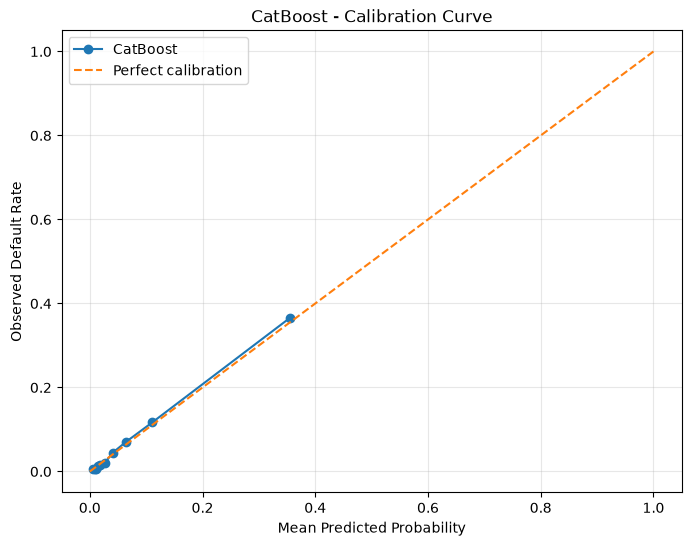

In [57]:
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='CatBoost'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.title('CatBoost - Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 10. Calibration Method Comparison

The tuned CatBoost model already shows good probability calibration.

Additional calibration methods are evaluated to determine whether
probability estimates can be improved further without sacrificing
ranking performance.

In [59]:
catboost_sigmoid = CalibratedClassifierCV(
    estimator=best_catboost,
    method='sigmoid',
    cv=5
)

catboost_sigmoid.fit(
    X_train[features],
    y_train
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",CatBoostClass...verbose=False)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0023F6EBF7E00>, <sk

In [60]:
sigmoid_valid_proba = catboost_sigmoid.predict_proba(
    X_valid[features]
)[:, 1]

In [61]:
catboost_isotonic = CalibratedClassifierCV(
    estimator=best_catboost,
    method='isotonic',
    cv=5
)

catboost_isotonic.fit(
    X_train[features],
    y_train
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",CatBoostClass...verbose=False)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0023F6EF3D250>, <s

In [62]:
isotonic_valid_proba = catboost_isotonic.predict_proba(
    X_valid[features]
)[:, 1]

In [63]:
calibration_comparison = pd.DataFrame({
    'Model': [
        'CatBoost',
        'CatBoost + Sigmoid',
        'CatBoost + Isotonic'
    ],
    'Brier Score': [
        brier_score_loss(
            y_valid,
            best_catboost_valid_proba
        ),
        brier_score_loss(
            y_valid,
            sigmoid_valid_proba
        ),
        brier_score_loss(
            y_valid,
            isotonic_valid_proba
        )
    ],
    'ROC-AUC': [
        roc_auc_score(
            y_valid,
            best_catboost_valid_proba
        ),
        roc_auc_score(
            y_valid,
            sigmoid_valid_proba
        ),
        roc_auc_score(
            y_valid,
            isotonic_valid_proba
        )
    ],
    'PR-AUC': [
        average_precision_score(
            y_valid,
            best_catboost_valid_proba
        ),
        average_precision_score(
            y_valid,
            sigmoid_valid_proba
        ),
        average_precision_score(
            y_valid,
            isotonic_valid_proba
        )
    ]
})

calibration_comparison

,Model,Brier Score,ROC-AUC,PR-AUC
0,CatBoost,0.048461,0.867100,0.407215
1,CatBoost + Sigmoid,0.050073,0.867073,0.406175
2,CatBoost + Isotonic,0.048445,0.866906,0.405632


In [64]:
final_model = best_catboost

In [65]:
final_valid_proba = best_catboost_valid_proba

## 11. Final CatBoost - Threshold Analysis

The final CatBoost model produces calibrated risk probabilities.

In [66]:
catboost_thresholds = np.arange(
    0.05,
    0.51,
    0.025
)

In [67]:
catboost_threshold_results = []

for threshold in catboost_thresholds:
    y_pred = (
        final_valid_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred
    ).ravel()

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    catboost_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

catboost_threshold_results = pd.DataFrame(
    catboost_threshold_results
)

catboost_threshold_results.round(4)

,Threshold,Precision,Recall,F1,TN,FP,FN,TP
0,0.050,0.1840,0.8367,0.3017,14414,5157,227,1163
1,0.075,0.2276,0.7453,0.3488,16056,3515,354,1036
2,0.100,0.2757,0.6763,0.3917,17101,2470,450,940
3,0.125,0.3238,0.6101,0.4230,17800,1771,542,848
4,0.150,0.3552,0.5647,0.4361,18146,1425,605,785
5,0.175,0.3845,0.5295,0.4455,18393,1178,654,736
6,0.200,0.4032,0.4871,0.4412,18569,1002,713,677
7,0.225,0.4168,0.4561,0.4356,18684,887,756,634
8,0.250,0.4390,0.4295,0.4342,18808,763,793,597
9,0.275,0.4598,0.4072,0.4319,18906,665,824,566


In [68]:
best_catboost_f1_row = (
    catboost_threshold_results
    .loc[
        catboost_threshold_results['F1'].idxmax()
    ]
)

best_catboost_f1_row

Threshold        0.175000
Precision        0.384535
Recall           0.529496
F1               0.445521
TN           18393.000000
FP            1178.000000
FN             654.000000
TP             736.000000
Name: 5, dtype: float64

In [69]:
FP_COST = 1
FN_COST = 5

In [70]:
catboost_cost_results = (
    catboost_threshold_results.copy()
)

catboost_cost_results['Total Cost'] = (
    FP_COST * catboost_cost_results['FP']
    + FN_COST * catboost_cost_results['FN']
)

best_catboost_cost_row = (
    catboost_cost_results
    .loc[
        catboost_cost_results['Total Cost'].idxmin()
    ]
)

best_catboost_cost_row

Threshold         0.175000
Precision         0.384535
Recall            0.529496
F1                0.445521
TN            18393.000000
FP             1178.000000
FN              654.000000
TP              736.000000
Total Cost     4448.000000
Name: 5, dtype: float64

In [71]:
FINAL_THRESHOLD = 0.175
final_model = best_catboost

In [72]:
final_metrics = pd.DataFrame({
    'Metric': [
        'ROC-AUC',
        'PR-AUC',
        'Brier Score',
        'Threshold',
        'Precision',
        'Recall',
        'F1'
    ],
    'Value': [
        best_catboost_roc_auc,
        best_catboost_pr_auc,
        catboost_brier,
        FINAL_THRESHOLD,
        best_catboost_f1_row['Precision'],
        best_catboost_f1_row['Recall'],
        best_catboost_f1_row['F1']
    ]
})

final_metrics

,Metric,Value
0,ROC-AUC,0.867100
1,PR-AUC,0.407215
2,Brier Score,0.048461
3,Threshold,0.175000
4,Precision,0.384535
5,Recall,0.529496
6,F1,0.445521
